# Create Data Splits for Training, Validation, and Testing

Author: Pete King

This notebook creates a separate dataset to hold in reserve for a final evaluation of our selected model's ability to generalize to unseen data (the "test" set), a dataset for model validation and hyperparameter tuning (the "validation" set), and a dataset for model training (the "training" set).

We want to rigorously test our final model against a period of dynamic real-world volatility.  For example, beginning in October 2024 would capture an initial period of relatively low volatility, followed by the highly volatility period after President Trump announced reciprocal tarrifs in April 2025.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import pandas as pd

import data_prep as dp

In [2]:
# Select the data files and start dates for validation and testing
ETF_FILENAME = 'etf_labelled.csv'
MACRO_FILENAME = 'fred_data.csv'
INDICIES_FILENAME = 'filled_indicies_data.csv'
VALIDATION_START_DATE = '2023-01-01'
TESTING_START_DATE = '2024-10-01'
# Depending on how we calculate our target variables, we may need a buffer
# between training and testing sets.
BUFFER_SIZE = 5  # Number of business days between splits

In [3]:
# Import feature datasets
etf_df = pd.read_csv(
    ETF_FILENAME,
    index_col='date',
    parse_dates=True
)
macro_df = pd.read_csv(
    MACRO_FILENAME,
    index_col='date',
    parse_dates=True
)
indicies_df = pd.read_csv(
    INDICIES_FILENAME,
    index_col='date',
    parse_dates=True
)

In [4]:
# Examine starting dates for ETF data - we want to go back to 2004
dp.get_start_dates(etf_df)

[('SPY_ret_target', Timestamp('1993-01-29 00:00:00')),
 ('SPY_ret', Timestamp('1993-02-01 00:00:00')),
 ('SPY_f-vol_target', Timestamp('1993-02-04 00:00:00')),
 ('SPY_h-vol', Timestamp('1993-02-05 00:00:00')),
 ('XLB_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLE_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLF_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLI_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLK_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLP_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLU_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLV_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLY_ret_target', Timestamp('1998-12-22 00:00:00')),
 ('XLB_f-vol_target', Timestamp('1998-12-22 00:00:00')),
 ('XLE_f-vol_target', Timestamp('1998-12-22 00:00:00')),
 ('XLF_f-vol_target', Timestamp('1998-12-22 00:00:00')),
 ('XLI_f-vol_target', Timestamp('1998-12-22 00:00:00')),
 ('XLK_f-vol_target', Timestamp('1998-12-22 00:00:00')),
 ('XLP_f-v

In [5]:
# We drop a few ETFs whose price histories don't go back to 2004
etf_df = etf_df.drop(
    columns=['BND_ret', 'BND_h-vol', 'BND_ret_target', 'BND_f-vol_target',
             'HYG_ret', 'HYG_h-vol', 'HYG_ret_target', 'HYG_f-vol_target',
             'BIL_ret', 'BIL_h-vol', 'BIL_ret_target', 'BIL_f-vol_target',
             'XLRE_ret', 'XLRE_h-vol', 'XLRE_ret_target', 'XLRE_f-vol_target'
            ]
).copy()

In [6]:
# Examine starting dates for macro data - we want to go back to 2004
dp.get_start_dates(macro_df)

[('nominal_GDP', Timestamp('1947-01-01 00:00:00')),
 ('real_GDP', Timestamp('1947-01-01 00:00:00')),
 ('debt_interest', Timestamp('1947-01-01 00:00:00')),
 ('consumer_price_index', Timestamp('1947-01-01 00:00:00')),
 ('unemployment_rate', Timestamp('1948-01-01 00:00:00')),
 ('teenager_unemployment_rate', Timestamp('1948-01-01 00:00:00')),
 ('adult_unemployment_rate', Timestamp('1948-01-01 00:00:00')),
 ('male_unemployment_rate', Timestamp('1948-01-01 00:00:00')),
 ('female_unemployment_rate', Timestamp('1948-01-01 00:00:00')),
 ('average_duration_of_unemployment', Timestamp('1948-01-01 00:00:00')),
 ('core_PCI', Timestamp('1957-01-01 00:00:00')),
 ('personal_consumption_expenditure', Timestamp('1959-01-01 00:00:00')),
 ('core_PCE', Timestamp('1959-01-01 00:00:00')),
 ('one_year_yield', Timestamp('1962-01-02 00:00:00')),
 ('five_year_yield', Timestamp('1962-01-02 00:00:00')),
 ('ten_year_yield', Timestamp('1962-01-02 00:00:00')),
 ('debt_to_GDP', Timestamp('1966-01-01 00:00:00')),
 ('in

In [7]:
# Since the PPI only goes back to 2009, we drop it from the data.
# We also implement a forward fill for imputation; this method chosen to 
# guard against data leakage in time-series data.
macro_df = macro_df.drop(columns=['producer_price_index']).ffill().copy()

In [8]:
# Merge the filled macroeconomic and indicies datasets to the ETF data
# IMPORTANT: We join on the ETF index to include only business days
# This is necessary for future volatility calculations based on business days
etf_macro_df = pd.merge(
    left=etf_df,
    right=macro_df,
    how='left',
    left_index=True,
    right_index=True
)
complete_df = pd.merge(
    left=etf_macro_df,
    right=indicies_df,
    how='left',
    left_index=True,
    right_index=True
)

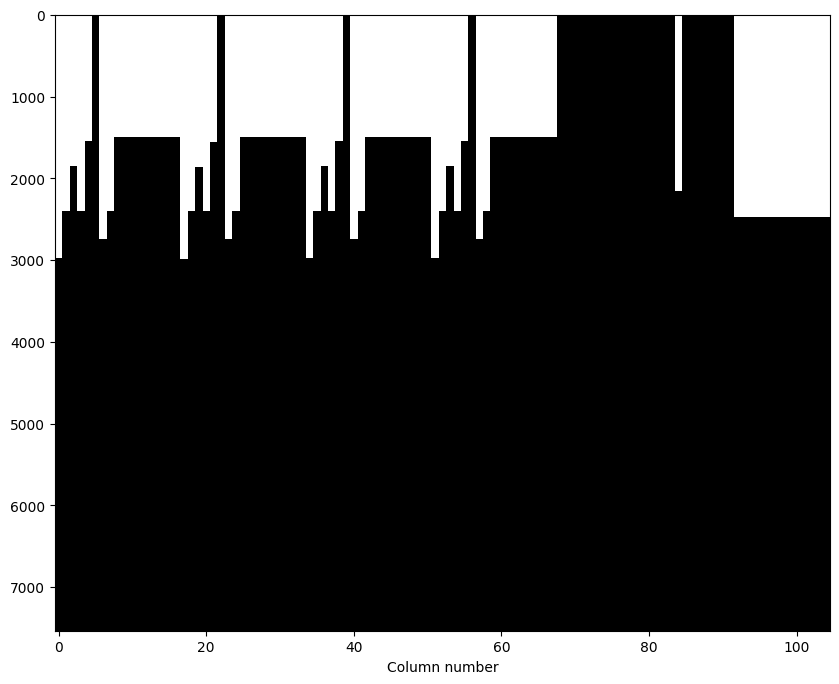

In [9]:
# Create separate training/validation and testing data files
train_val_df, test_df = dp.time_series_split(
    complete_df, TESTING_START_DATE, BUFFER_SIZE
)
train_df, val_df = dp.time_series_split(
    train_val_df, VALIDATION_START_DATE, BUFFER_SIZE
)
dp.view_nan(train_df);

In [10]:
# Drop NA rows from the training DF so we have a common start date
train_df = train_df.dropna().copy()
train_df

,GLD_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,TLT_ret,XLB_ret,XLE_ret,...,HG=F,NG=F,SHY,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
2004-11-26,0.005313,-0.003638,0.000638,-0.003578,-0.003056,-0.000760,-0.003977,-0.006552,0.009809,0.004258,...,1.4885,7.976,54.425610,4741.600098,1182.650024,13895.030273,84.900002,4.238,12.780000,17.940001
2004-11-29,0.002426,-0.006011,0.003579,-0.007917,-0.000254,-0.004573,-0.004563,-0.010709,-0.002696,-0.005325,...,1.4450,7.837,54.432301,4749.799805,1178.569946,14066.910156,90.650002,4.330,13.300000,18.830000
2004-11-30,-0.006187,-0.000946,0.007357,0.001264,-0.002043,0.000678,-0.001240,-0.004246,-0.004058,0.001334,...,1.4430,7.620,54.445652,4703.200195,1173.819946,14060.049805,89.559998,4.358,13.240000,18.840000
2004-12-01,0.005746,-0.000332,0.009257,-0.000598,0.020243,0.011303,-0.001694,-0.001562,0.009108,-0.024286,...,1.4675,7.413,54.482410,4735.700195,1191.369995,14162.799805,88.230003,4.375,12.970000,18.240000
2004-12-02,-0.009521,-0.002259,-0.001407,-0.003178,0.003751,0.000838,-0.002398,-0.004056,-0.012502,-0.026853,...,1.4370,6.811,54.462379,4751.200195,1190.329956,14261.790039,91.230003,4.397,12.980000,18.639999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-19,-0.002822,-0.008146,-0.013627,-0.010137,-0.014153,-0.008516,-0.003445,-0.016948,-0.013080,-0.000120,...,3.7830,5.851,72.634155,7361.299805,3817.659912,19352.810547,118.320000,3.581,22.420000,27.410000
2022-12-20,0.016458,-0.007286,0.005277,-0.011834,-0.000779,0.001367,-0.000280,-0.017917,0.006555,0.014979,...,3.7975,5.326,72.634155,7370.600098,3821.620117,19094.800781,119.919998,3.684,21.480000,26.650000
2022-12-21,-0.001657,0.001235,0.017087,0.006819,0.014402,0.014842,0.005397,0.002511,0.008674,0.018819,...,3.8060,5.332,72.705605,7497.299805,3878.439941,19160.490234,115.000000,3.684,20.070000,25.150000


In [11]:
val_df

,GLD_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,TLT_ret,XLB_ret,XLE_ret,...,HG=F,NG=F,SHY,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.008336,0.007800,-0.005521,0.006900,-0.006783,-0.004219,0.003564,0.018904,-0.001030,-0.035728,...,3.7660,3.988,72.553772,7554.100098,3824.139893,20145.289062,129.970001,3.793,22.900000,29.110001
2023-01-04,0.009368,0.007637,0.012380,0.007227,0.004753,0.007690,0.000655,0.013607,0.017247,-0.000118,...,3.7395,4.172,72.625214,7585.200195,3852.969971,20793.109375,125.779999,3.709,22.010000,28.360001
2023-01-05,-0.012530,-0.001440,-0.010767,-0.000749,-0.015779,-0.011479,0.000281,0.004172,-0.015960,0.018084,...,3.8180,3.720,72.526955,7633.500000,3808.100098,21052.169922,119.529999,3.720,22.459999,28.809999
2023-01-06,0.018535,0.012787,0.022207,0.016245,0.027228,0.022673,0.009124,0.018230,0.033786,0.018791,...,3.9085,3.710,72.803825,7699.500000,3895.080078,20991.640625,113.870003,3.569,21.129999,26.959999
2023-01-09,0.002243,0.002538,0.001688,0.003952,0.006453,-0.000567,0.002314,0.005310,0.006326,-0.003547,...,4.0185,3.910,72.875282,7724.899902,3892.090088,21388.339844,116.669998,3.517,21.969999,27.860001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-17,-0.005546,-0.001817,0.008238,0.000088,0.000528,0.000409,-0.000361,-0.004847,0.001922,0.013424,...,4.2135,2.324,78.518234,8309.900391,5634.580078,17660.019531,101.580002,3.642,17.610001,22.690001
2024-09-18,-0.007740,-0.004355,0.000182,-0.004141,-0.004339,-0.002970,-0.003708,-0.012473,-0.004277,0.001936,...,4.2380,2.284,78.489922,8253.700195,5618.259766,17660.019531,98.610001,3.685,18.230000,22.709999
2024-09-19,0.015421,-0.000813,0.020388,0.000883,0.024970,0.016920,0.002985,-0.003319,0.014995,0.011873,...,4.2860,2.348,78.556030,8328.700195,5713.640137,18013.160156,92.639999,3.740,16.330000,21.090000


In [12]:
test_df

,GLD_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,TLT_ret,XLB_ret,XLE_ret,...,HG=F,NG=F,SHY,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
2024-10-01,0.010437,0.003632,-0.013675,0.004794,-0.014030,-0.008999,0.003275,0.007194,-0.002493,0.022523,...,4.5355,2.896,78.577927,8276.700195,5708.750000,21133.679688,104.139999,3.743,19.260000,21.670000
2024-10-02,0.000204,-0.002855,-0.001378,-0.002213,0.001412,0.000422,-0.000904,-0.008463,-0.003856,0.010193,...,4.5960,2.886,78.558960,8290.900391,5709.540039,22443.730469,102.169998,3.785,18.900000,21.350000
2024-10-03,-0.000692,-0.005120,-0.006732,-0.006489,-0.000747,-0.001830,-0.004258,-0.009465,-0.011130,0.017483,...,4.5020,2.970,78.454727,8282.500000,5699.939941,22113.509766,101.160004,3.850,20.490000,22.480000
2024-10-04,-0.001998,-0.009697,0.013876,-0.005455,0.011828,0.009046,-0.006833,-0.012377,0.004845,0.009272,...,4.5225,2.854,78.189407,8280.599609,5751.069824,22736.869141,100.150002,3.981,19.209999,21.639999
2024-10-07,-0.003394,-0.003635,-0.007880,-0.005124,-0.010769,-0.009081,-0.001098,-0.007564,-0.002946,0.003535,...,4.5190,2.746,78.085205,8303.599609,5695.939941,23099.779297,124.230003,4.026,22.639999,24.340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13,-0.013021,-0.001046,-0.003320,-0.003691,-0.005945,-0.005676,-0.001985,-0.004957,-0.009912,0.003298,...,5.7145,3.131,82.550003,10261.200195,6632.189941,25465.599609,91.169998,4.285,27.190001,29.870001
2026-03-16,-0.000890,0.004488,0.009405,0.004796,0.011155,0.010125,0.003156,0.007712,0.004260,0.003460,...,5.7905,3.023,82.650002,10317.700195,6699.379883,25834.019531,85.250000,4.220,23.510000,26.320000
2026-03-17,-0.002523,0.001769,0.006307,0.005597,0.004868,0.002627,0.003505,0.002748,0.002426,0.010480,...,5.7265,3.033,82.660004,10403.599609,6716.089844,25868.539062,79.230003,4.202,22.370001,24.660000


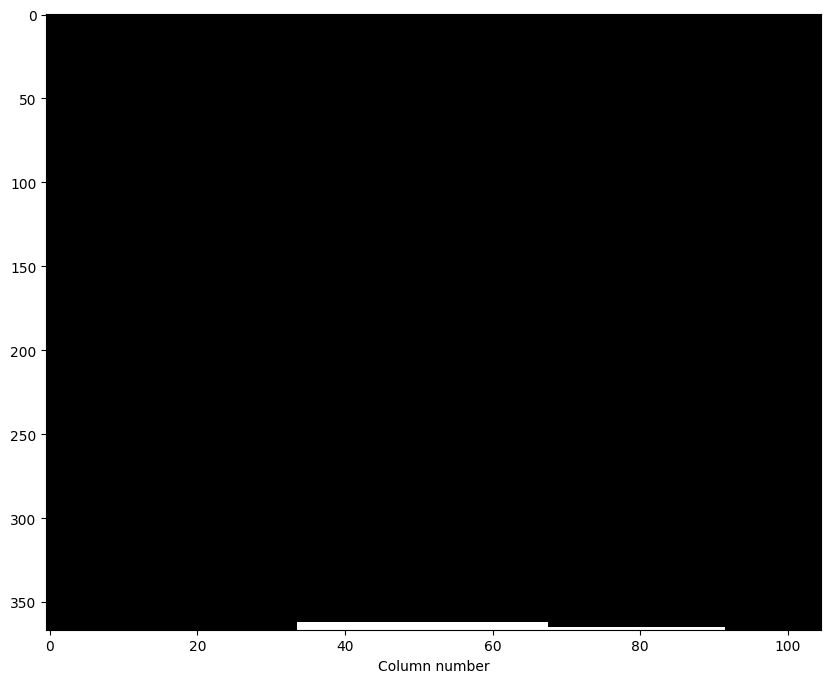

In [13]:
dp.view_nan(test_df);

In [14]:
# Drop NA rows from the testing DF where some return data is missing at the end
test_df = test_df.dropna().copy()

In [15]:
# Get column names for breaking out separate datasets by type
etf_cols = [column for column in etf_df.columns]
macro_cols = [column for column in macro_df.columns]
indicies_cols = [column for column in indicies_df.columns]

In [16]:
DATA_FOLDER  = 'data/train-val-test/'
# Save complete segmented datasets
train_df.to_csv(DATA_FOLDER + 'train_ALL_DATA.csv')
val_df.to_csv(DATA_FOLDER + 'val_ALL_DATA.csv')
test_df.to_csv(DATA_FOLDER + 'test_ALL_DATA.csv')

# Save etf datasets
train_df[etf_cols].to_csv(DATA_FOLDER + 'train_etf_data.csv')
val_df[etf_cols].to_csv(DATA_FOLDER + 'val_etf_data.csv')
test_df[etf_cols].to_csv(DATA_FOLDER + 'test_etf_data.csv')

# Save macroeconomic datasets
train_df[macro_cols].to_csv(DATA_FOLDER + 'train_macro_data.csv')
val_df[macro_cols].to_csv(DATA_FOLDER + 'val_macro_data.csv')
test_df[macro_cols].to_csv(DATA_FOLDER + 'test_macro_data.csv')

# Save indicies datasets
train_df[indicies_cols].to_csv(DATA_FOLDER + 'train_indicies_data.csv')
val_df[indicies_cols].to_csv(DATA_FOLDER + 'val_indicies_data.csv')
test_df[indicies_cols].to_csv(DATA_FOLDER + 'test_indicies_data.csv')